## Code Ready

### Sandart Intel

In [ ]:
import sqlite3
import pandas as pd

In [ ]:
# Caminho do banco de dados SQLite
db_path = r"D:\Fausto Stangler\Documentos\Python\FLY\backend\data\app_raw.db"

# Conectar ao banco de dados
conn = sqlite3.connect(db_path)

# Carregar os dados
df = pd.read_sql("SELECT * FROM tbl_statements_normalized", conn)  # Dados já processados

# Fechar a conexão com o banco de dados
conn.close()

df = df.loc[df.groupby(["company_name", "quarter", "type"])["version"].idxmax()]

In [ ]:
df.columns

In [ ]:
mask = df["company_name"] == "ALPARGATAS SA"
mask &= df["account"] == "02"
mask &= df["type"] == "DFs Consolidadas"

df["account"].unique()

In [ ]:
import sqlite3
import pandas as pd

# Caminho do banco de dados SQLite
db_path = r"D:\Fausto Stangler\Documentos\Python\FLY\backend\data\app_raw.db"

# Conectar ao banco de dados
conn = sqlite3.connect(db_path)

# Query SQL para carregar APENAS os dados que ainda não foram processados
query = """
SELECT 
FROM tbl_statements_raw
LEFT JOIN tbl_statements_normalized
ON tbl_statements_raw.company_name = tbl_statements_normalized.company_name
AND tbl_statements_raw.quarter = prtbl_statements_normalizedocessed.quarter
AND tbl_statements_raw.type = proctbl_statements_normalizedessed.type
AND tbl_statements_raw.frame = tbl_statements_normalized.frame
WHERE tbl_statements_normalized.company_name IS NULL;
"""

# Executar a query no banco de dados e carregar no pandas
df = pd.read_sql(query, conn)

# Fechar a conexão com o banco de dados
conn.close()

# Agora `financial_statements` contém apenas os registros que ainda NÃO foram processados
df

In [ ]:
df

In [ ]:
financial_statements = pd.read_csv("financial_statements.csv")
standart_statements = pd.read_csv("standart_statements.csv")
primary_key_columns = ["company_name", "quarter", "version", "type", "frame"]

In [ ]:
financial_statements

In [ ]:
df = pd.merge(
    standart_statements, financial_statements[primary_key_columns], on=primary_key_columns, how="left", indicator=True
)
df

### Stock Splits with YFinance

In [ ]:
# mesclar as cotações históricas do yfinance, com as stocks dos statements ajustadas pela data exata (e não trimestral) do split pelo yfinance.

# para cada stock_ticker (BBAS3, etc), scrape historical_data do yahoo finance (já ajustado)

# para cada stock_ticker, pegar o calendário de splits (similar acima, mas somente as datas (que são iguais) e os splits)

# fazer um merge do statements por trimestre com o stock_splits por dia e ajustar a quantidade de ações quando houver split. A questão é saber quando a quantidade precisa ser ajustasa e quando la já está ajustada.
# Eu sei que no começo de cada trimestre a quantidade de stocks já está corrigida, e no começo do trimestre anterior ela está antiga. Em algum momento houve a mudança, e a data exata está
# no stock_split. Então quando o stock_split tiver uma informação, para aquele quarter eu preciso deixar o valor como está desta data-ex do stock_split para antes, e ajustar a quantidade de ações
# (dependendo se é grupamento ou desdobramento) para a quantidade de ações do statements desta data em diante. REpetindo, da data_ex (via stock_splits) para antes, copiar o valor diário do
# statements (que está trimestral) e da data-ex para diante, ajustar a quantidade de stocks do statements conforme o valor do split no stock_splits, e deixar como valor diário)

# Usar o BBAS3 como exemplo para 2024 quando houve stock_split

# então tem que abrir cxompany_info, iterar até bbas3, e então abrir statements do bbas3 e download historical_data e stock_splits do yfinance. Esses dados do yfinance podem ser salvos
# no metadados db, mas vão estar sempre defasados. Então na verdade, tem que abrir do historical_data e stock_splits, fazer um update com start_date só mais recente, limpar os dados
# proceder com o merge, e então atualizar o metadados db.

# e então calcular por exemplo, o preço por ação (porque a quantiade de ações vai estar certa a cada dia)

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import os
import sys

In [ ]:
# imports
# Add the backend folder to the Python path
backend_dir = os.path.join(os.getcwd(), "backend")
if backend_dir not in sys.path:
    sys.path.append(backend_dir)
from utils.corporate_events_processor import CorporateEventsProcessor

self = CorporateEventsProcessor()

In [ ]:
# get yfinance data and yfinance splits
company_name = "BCO BRASIL SA"
ticker = ticker_code = "BBAS3"
start_date = "1960-01-01"


historical_splits = yf.download(
    ticker + ".SA", start=start_date, progress=False, actions=True, auto_adjust=True
).reset_index()
historical_splits.columns = historical_splits.columns.get_level_values(0).rename(None)
historical_splits = historical_splits[["Date", "Dividends", "Stock Splits"]]
historical_splits = historical_splits.loc[
    ~((historical_splits["Dividends"] == 0) & (historical_splits["Stock Splits"] == 0))
]
historical_splits.replace(0, np.nan, inplace=True)

historical_data = yf.download(
    ticker + ".SA", start=start_date, progress=False, actions=True, auto_adjust=True
).reset_index()
# historical_data.columns = historical_data.columns.get_level_values(0).rename(None)

In [ ]:
ticker_obj = yf.Ticker(ticker_code + ".SA")
historical_data = ticker_obj.history(start=start_date, actions=True, auto_adjust=True).reset_index()
historical_data.columns = historical_data.columns.str.lower().str.replace(" ", "_")
historical_data["date"] = pd.to_datetime(historical_data["date"]).dt.strftime("%Y-%m-%d")
historical_data["company_name"] = company_name
historical_data["ticker"] = ticker
historical_data["ticker_code"] = ticker_code
historical_data = historical_data[self.config.historical_stock_data_all_columns]

In [ ]:
mask = historical_data["stock_splits"] != 0
historical_data[mask][["date", "stock_splits"]]

In [ ]:
historical_data.columns

In [ ]:
historical_data

In [ ]:
historical_data

In [ ]:
historical_data

In [ ]:
historical_splits

In [ ]:
historical_splits[historical_splits["Stock Splits"].notnull()][["Date", "Stock Splits"]]

In [ ]:
# from statements, get stock_quantity and put it from quarters to daily basis

# merge statements_stock_quantity with daily_splits to apply changes to stock quantity

# from yfinance data merge by date to stock_quantity_adjusted to get stock_value_and_quantity

In [ ]:
ticker = "AFYA5"
historical_splits = yf.download(
    ticker + ".SA", start=start_date, progress=False, actions=True, auto_adjust=True
).reset_index()
historical_splits

### Historical Data yFinance

In [ ]:
ticker = "BBAS3"
ticker_code = ticker + ".SA"
start_date = "1960-01-01"


data = yf.download(ticker_code, start=start_date, progress=False, actions=True, auto_adjust=True).reset_index()

In [ ]:
data

In [ ]:
data.to_csv(f"{ticker}_yahoo.csv", index=False)

### Request Cloudflare

In [ ]:
import requests
import json
from urllib.parse import quote
import pandas as pd
import time
import random
import cloudscraper


In [ ]:
user_agents = [
    # Chrome (Windows, macOS, Linux, Android)
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 12_6_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36",
    "Mozilla/5.0 (Android 13; Mobile; SM-S908B) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Mobile Safari/537.36",
    # Firefox (Windows, macOS, Linux, Android)
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:115.0) Gecko/20100101 Firefox/115.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 12_6_1; rv:115.0) Gecko/20100101 Firefox/115.0",
    "Mozilla/5.0 (X11; Linux x86_64; rv:115.0) Gecko/20100101 Firefox/115.0",
    "Mozilla/5.0 (Android 13; Mobile; SM-S908B; rv:115.0) Gecko/115.0 Firefox/115.0",
    # Safari (macOS, iOS)
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 12_6_1) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.0 Safari/605.1.15",
    "Mozilla/5.0 (iPhone; CPU iPhone OS 16_5 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.5 Mobile/15E148 Safari/604.1",
    "Mozilla/5.0 (iPad; CPU OS 16_5 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.5 Mobile/15E148 Safari/604.1",
    # Microsoft Edge (Windows, macOS)
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 Edg/114.0.1823.82",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 12_6_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 Edg/114.0.1823.82",
    # Brave (Windows, macOS, Linux)
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 Brave/1.57.57",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 12_6_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 Brave/1.57.57",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 Brave/1.57.57",
    # Opera (Windows, macOS)
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 OPR/99.0.4788.88",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 12_6_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 OPR/99.0.4788.88",
    # Samsung Internet (Android)
    "Mozilla/5.0 (Linux; Android 13; SM-S908B) AppleWebKit/537.36 (KHTML, like Gecko) SamsungBrowser/22.0 Chrome/114.0.5735.199 Mobile Safari/537.36",
    # Vivaldi Browser (Desktop and Android)
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 Vivaldi/6.1.3035.111",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 12_6_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 Vivaldi/6.1.3035.111",
    "Mozilla/5.0 (Android 13; Mobile; SM-S908B) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 Vivaldi/6.1.3035.111",
    # Yandex Browser (Russia and CIS)
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 YaBrowser/23.7.3.652 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 12_6_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 YaBrowser/23.7.3.652 Safari/537.36",
    "Mozilla/5.0 (Android 13; Mobile; SM-S908B) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 YaBrowser/23.7.3.652 Mobile Safari/537.36",
    # Xbox and PlayStation Browsers
    "Mozilla/5.0 (Xbox; U; Windows NT 10.0; WOW64; en-US) AppleWebKit/537.36 (KHTML, like Gecko) Edge/44.18363.8131",
    "Mozilla/5.0 (PlayStation 5; AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36",
    # Samsung Galaxy Tablet (Android)
    "Mozilla/5.0 (Linux; Android 13; SM-T970) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36",
    # Googlebot Mobile and Desktop (SEO Testing)
    "Mozilla/5.0 (Linux; Android 13; SM-S908B) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Mobile Safari/537.36 Googlebot/2.1",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.5735.199 Safari/537.36 Googlebot/2.1",
]

referers = [
    "https://www.google.com/",
    "https://www.bing.com/",
    "https://www.duckduckgo.com/",
    "https://www.facebook.com/",
    "https://twitter.com/",
    "https://www.reddit.com/",
    "https://www.youtube.com/",
    "https://www.linkedin.com/",
    "https://www.instagram.com/",
    "https://www.tiktok.com/",
    "https://www.wikipedia.org/",
    "https://www.amazon.com/",
    "https://www.ebay.com/",
    "https://www.alibaba.com/",
    "https://www.github.com/",
    "https://stackoverflow.com/",
    "https://www.quora.com/",
    "https://news.ycombinator.com/",
    "https://www.netflix.com/",
    "https://www.twitch.tv/",
    "https://www.spotify.com/",
    "https://www.medium.com/",
    "https://www.dropbox.com/",
    "https://www.paypal.com/",
    "https://www.apple.com/",
    "https://www.microsoft.com/",
    "https://www.adobe.com/",
]

languages = [
    "en-US;q=1.0",  # English (United States)
    "en-GB;q=0.9",  # English (United Kingdom)
    "es-ES;q=0.9",  # Spanish (Spain)
    "es-MX;q=0.8",  # Spanish (Mexico)
    "fr-FR;q=0.9",  # French (France)
    "de-DE;q=0.9",  # German (Germany)
    "it-IT;q=0.8",  # Italian (Italy)
    "pt-BR;q=0.9",  # Portuguese (Brazil)
    "pt-PT;q=0.8",  # Portuguese (Portugal)
    "ja-JP;q=0.8",  # Japanese
    "zh-CN;q=0.8",  # Chinese (Simplified)
    "zh-TW;q=0.7",  # Chinese (Traditional)
    "ko-KR;q=0.8",  # Korean
    "ru-RU;q=0.9",  # Russian
    "ar-SA;q=0.8",  # Arabic (Saudi Arabia)
    "hi-IN;q=0.8",  # Hindi (India)
    "tr-TR;q=0.8",  # Turkish
    "nl-NL;q=0.8",  # Dutch (Netherlands)
    "sv-SE;q=0.8",  # Swedish (Sweden)
    "pl-PL;q=0.8",  # Polish
    "da-DK;q=0.8",  # Danish (Denmark)
    "no-NO;q=0.8",  # Norwegian
    "cs-CZ;q=0.8",  # Czech (Czech Republic)
    "el-GR;q=0.8",  # Greek
    "th-TH;q=0.8",  # Thai
    "id-ID;q=0.8",  # Indonesian
]
def gerar_headers():
    return {
        "User-Agent": random.choice(user_agents),
        "Accept": "application/json, text/plain, */*",
        "Accept-Language": random.choice(languages),
        "Referer": random.choice(referers),
    }


In [ ]:
def base64_decode(token_base64: str) -> dict:
    """
    Decodifica um payload Base64 da B3 e retorna como dicionário JSON.

    Args:
        token_base64 (str): Token codificado (ex: 'eyJsYW5ndWFnZSI6InB0LWJyIn0=')

    Returns:
        dict: Dicionário com os dados decodificados
    """
    if token_base64.startswith("https"):
        token_base64 = token_base64.rstrip("/").split("/")[-1]

    try:
        decoded_bytes = base64.b64decode(token_base64)
        decoded_str = decoded_bytes.decode()
        return json.loads(decoded_str)
    except Exception as e:
        print(f"[ERRO] Falha ao decodificar: {e}")
        return {}

def base64_payload(payload: dict) -> str:
    """
    Gera um token Base64 com os parâmetros corretos para o endpoint da B3.

    Args:
        payload (dict): Dicionário com parâmetros como language, pageNumber, etc.

    Returns:
        str: String Base64 pronta para ser usada na URL.
    """
    json_str = json.dumps(payload, separators=(',', ':'))
    base64_encoded = base64.b64encode(json_str.encode()).decode()
    return base64_encoded


In [ ]:
companies = pd.read_csv(r'D:\Fausto Stangler\Documentos\Python\FLY\targets.csv')

In [ ]:
# Criar uma sessão
# session = requests.Session()
scraper = cloudscraper.create_scraper()

# Passo 2: Fazer a primeira requisição (gera os cookies)
url = "https://sistemaswebb3-listados.b3.com.br/listedCompaniesPage/?language=pt-br"
# response_start = session.get(url, headers=headers)
response_start = scraper.get(url, headers=gerar_headers())


In [ ]:
payload_1 = {"language": "pt-br", "pageNumber": 1, "pageSize": 120}
token_1 = base64_payload(payload_1)
url_1 = f'https://sistemaswebb3-listados.b3.com.br/listedCompaniesProxy/CompanyCall/GetInitialCompanies/{token_1}'
response_1 = scraper.get(url_1, headers=gerar_headers())
companies = response_1.json()


In [ ]:
companies['page']['totalPages']

In [ ]:
all_results = []
for i in range(1, companies['page']['totalPages'] + 1):
  payload_2 = {
  "language": "pt-br",
  "pageNumber": i,
  "pageSize": 120
  }
  token_2 = base64_payload(payload_2)
  url_2 = f'https://sistemaswebb3-listados.b3.com.br/listedCompaniesProxy/CompanyCall/GetInitialCompanies/{token_2}'

  response_2 = scraper.get(url_2, headers=gerar_headers())
  companies = response_2.json()
  results = companies['results']
  all_results.extend(results)
df_empresas = pd.DataFrame(all_results)
issuing_company_list = df_empresas['issuingCompany'].dropna().unique().tolist()


In [ ]:
# Define at the beginning of your script
total_block_time = 0  # Global counter

def get_company_data(issuing_company):
    global total_block_time

    wait_time = 1
    block_start_time = None
    block_duration = 0

    payload = {
        "language": "pt-br",
        "pageNumber": 1,
        "pageSize": 20,
        "company": issuing_company
    }

    token = base64_payload(payload)
    url = f"https://sistemaswebb3-listados.b3.com.br/listedCompaniesProxy/CompanyCall/GetInitialCompanies/{token}"

    # Initial scraper setup
    scraper = cloudscraper.create_scraper()

    while True:
        try:
            headers = gerar_headers()
            response = scraper.get(url, headers=headers)
            status = response.status_code

            if status == 200:
                if block_start_time:
                    release_time = time.time()
                    duration = release_time - block_start_time
                    total_block_time += duration
                    print(f"Total block time so far: {total_block_time:.2f}s ({total_block_time/60:.2f} min)")
                    block_start_time = None
                    block_duration = 0

                    # Create a new scraper instance to refresh Cloudflare context
                    scraper = cloudscraper.create_scraper()
                    homepage_url = "https://sistemaswebb3-listados.b3.com.br/listedCompaniesPage/?language=pt-br"
                    scraper.get(homepage_url, headers=headers)
                    print("🌐 New scraper session initialized")

                data = response.json()
                results = data.get("results", [])
                result = next((item for item in results if item.get("issuingCompany") == issuing_company), None)
                return result

            if not block_start_time:
                block_start_time = time.time()

            print(f"[{issuing_company}] ❌ Status {status} - waiting {wait_time}s")
            time.sleep(wait_time + random.uniform(0.3, 0.9))
            block_duration += wait_time
            wait_time += 1

        except Exception as e:
            if not block_start_time:
                block_start_time = time.time()
            print(f"[{issuing_company}] ⚠️ Exception: {e} - waiting {wait_time}s")
            time.sleep(wait_time + random.uniform(0.3, 0.9))
            block_duration += wait_time
            wait_time += 1


In [ ]:
all_data = []
for i, issuingCompany in enumerate(issuing_company_list):
    dados = get_company_data(issuingCompany)
    if dados:
        print(i, issuingCompany, dados['codeCVM'], time.time())
        all_data.append(dados)
    else:
        print(f'erro {issuingCompany}')

In [ ]:
df = pd.DataFrame(all_data)
df

In [ ]:
token = 'eyJsYW5ndWFnZSI6InB0LWJyIn0='
base64_decode(token)

In [ ]:
url = 'https://sistemaswebb3-listados.b3.com.br/listedCompaniesProxy/CompanyCall/GetIndustryClassification/eyJsYW5ndWFnZSI6InB0LWJyIn0='
industry_data = scraper.get(url)
dados = industry_data.json()  # ou json.loads(res2.text)
# Expandir para DataFrame
rows = []
for setor in dados:
    nome_setor = setor["sector"]
    for subsetor in setor.get("subSectors", []):
        nome_subsetor = subsetor["describle"]
        for segmento in subsetor.get("segment", []):
            rows.append({
                "Setor": nome_setor,
                "Subsetor": nome_subsetor,
                "Segmento": segmento
            })

sss = pd.DataFrame(rows)
sss

In [ ]:
sss = sss.rename(columns={
    "Segmento": "segment",
    "Setor": "sector",
    "Subsetor": "subsector"
})
df = df.merge(sss, on="segment", how="left")
df

### Clean SQLITE

In [ ]:
import sqlite3

# Caminho para seu banco de dados
db_path = r"D:\Fausto Stangler\Documentos\Python\FLY\backend\data\app_raw.db"

# Abrir conexão exclusiva
conn = sqlite3.connect(db_path)

# Forçar checkpoint completo
result = conn.execute("PRAGMA wal_checkpoint(FULL);").fetchall()
print("Resultado do checkpoint:", result)

conn.close()


Resultado do checkpoint: [(0, 0, 0)]


In [5]:
import sqlite3

# Caminho para seu banco de dados
db_path = r"D:\Fausto Stangler\Documentos\Python\FLY\backend\data\app_raw.db"

# Conectar ao banco
conn = sqlite3.connect(db_path)

# Checkpoint forçado para consolidar dados e zerar o .wal
checkpoint_result = conn.execute("PRAGMA wal_checkpoint(FULL);").fetchall()
print("Resultado checkpoint:", checkpoint_result)

# Reindexa todos os índices
print("Executando REINDEX...")
conn.execute("REINDEX;")

# Atualiza estatísticas para o otimizador
print("Executando ANALYZE...")
conn.execute("ANALYZE;")

# VACUUM deve ser feito com journal_mode=DELETE
print("Revertendo para modo DELETE para fazer VACUUM...")
conn.execute("PRAGMA journal_mode=DELETE;")

# VACUUM reorganiza fisicamente e reduz o tamanho do .db
print("Executando VACUUM (pode demorar)...")
conn.execute("VACUUM;")

# Verifica journal mode final
final_mode = conn.execute("PRAGMA journal_mode;").fetchone()[0]
print("Modo de journal após VACUUM:", final_mode)

# Reativa WAL se desejar continuar usando
print("Reativando WAL após VACUUM...")
conn.execute("PRAGMA journal_mode=WAL;")

# Finaliza
conn.close()
print("Manutenção concluída.")


Resultado checkpoint: [(1, 1441583, 0)]
Executando REINDEX...
Executando ANALYZE...
Revertendo para modo DELETE para fazer VACUUM...


OperationalError: database is locked

## Playground

### intel_processor

In [2]:
import sqlite3
import pandas as pd
import time

In [2]:
db_path = r"D:\Fausto Stangler\Documentos\Python\FLY\backend\data\app_raw.db"
conn = sqlite3.connect(db_path)


In [3]:
csv_raw = r"D:\Fausto Stangler\Documentos\Python\FLY\tbl_statements_raw.csv"
df_raw = pd.read_csv(csv_raw)

C:\Users\faust\AppData\Local\Temp\ipykernel_14148\881524150.py:2: DtypeWarning: Columns (6,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(csv_raw)


In [32]:
mask = (
    df_raw["processed"].isna() | (df_raw["processed"] != df_raw["version"])
)
        
df_raw[mask]


,nsd,sector,subsector,segment,company_name,quarter,version,type,frame,account,description,value,processed


In [4]:
csv_norm = r"D:\Fausto Stangler\Documentos\Python\FLY\tbl_statements_normalized.csv"
df_norm = pd.read_csv(csv_norm)

C:\Users\faust\AppData\Local\Temp\ipykernel_14148\3115803929.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_norm = pd.read_csv(csv_norm)


In [8]:
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5866000 entries, 0 to 5865999
Data columns (total 16 columns):
 #   Column          Dtype  
---  ------          -----  
 0   nsd             int64  
 1   sector          object 
 2   subsector       object 
 3   segment         object 
 4   company_name    object 
 5   quarter         object 
 6   version         object 
 7   type            object 
 8   frame           object 
 9   account         object 
 10  description     object 
 11  value           float64
 12  original_value  float64
 13  year            float64
 14  quarter_num     float64
 15  account_prefix  float64
dtypes: float64(5), int64(1), object(10)
memory usage: 716.1+ MB


<Axes: >

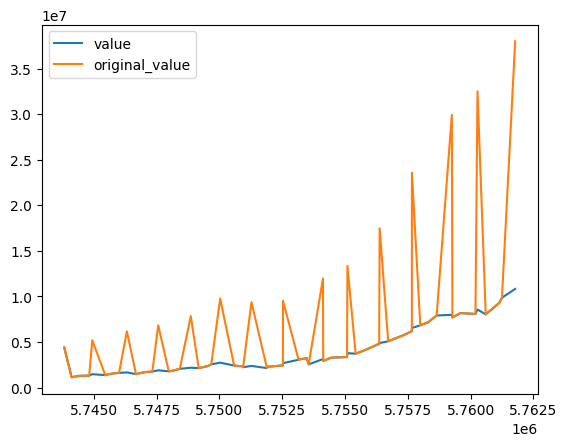

In [27]:
company_name = 'WEG SA'
typ = 'DFs Consolidadas'
account = '03.01'

mask = df_norm['company_name'] == company_name
mask&= df_norm['type'] == typ
mask&= df_norm['account'] == account

df_norm[mask].sort_values(by="quarter")

df_norm[mask][['quarter', 'value', 'original_value']].plot()

In [3]:
import pandas as pd

# Caminho local para o arquivo (ajuste conforme necessário)
file_path = "D:/Fausto Stangler/Documentos/Python/FLY/backend/data/COTAHIST_A2013.TXT"

# Definição das colunas fixas de acordo com o layout padrão da B3
colspecs = [
    (2, 10),   # data_pregao
    (12, 24),  # codigo_bdi_negociacao
    (24, 36),  # nome_papel
    (36, 48),  # especificacao_papel
    (48, 51),  # tipo_mercado
    (51, 54),  # moeda_referencia
    (56, 69),  # preco_abertura
    (69, 82),  # preco_maximo
    (82, 95),  # preco_minimo
    (95, 108), # preco_medio
    (108, 121),# preco_fechamento
    (121, 134),# preco_melhor
    (134, 147),# preco_ultima
    (152, 170),# volume_total
]

# Nomes das colunas
col_names = [
    "data_pregao",
    "codigo_bdi_negociacao",
    "nome_papel",
    "especificacao_papel",
    "tipo_mercado",
    "moeda_referencia",
    "preco_abertura",
    "preco_maximo",
    "preco_minimo",
    "preco_medio",
    "preco_fechamento",
    "preco_melhor",
    "preco_ultima",
    "volume_total"
]

# Leitura do arquivo
df = pd.read_fwf(file_path, colspecs=colspecs, names=col_names, encoding="latin1")

# Limpar entradas inválidas (linha de header/trailer que não contém código numérico)
df = df[df['codigo_bdi_negociacao'].str.contains(r'\d', na=False)]

# # Conversão dos campos monetários
# preco_cols = [c for c in df.columns if "preco_" in c]
# df[preco_cols] = df[preco_cols].apply(lambda x: x.astype(str).str.zfill(13).astype(float) / 100)

# # Conversão de volume para inteiro
# df["volume_total"] = df["volume_total"].astype(str).str.zfill(18).astype(int)

# # Conversão de data
# df["data_pregao"] = pd.to_datetime(df["data_pregao"], format="%Y%m%d")

# Exibir primeiras linhas
df.head()


,data_pregao,codigo_bdi_negociacao,nome_papel,especificacao_papel,tipo_mercado,moeda_referencia,preco_abertura,preco_maximo,preco_minimo,preco_medio,preco_fechamento,preco_melhor,preco_ultima,volume_total
0,COTAHIST,013BOVESPA 2,0131230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20130102,AAPL11B,010APPLE,DRN M,B,R$,11200.0,11200.0,11200.0,11200.0,11200.0,10915.0,11420.0,400.0
2,20130102,ABCB4,010ABC BRASI,L PN N,2,R$,1400.0,1427.0,1400.0,1414.0,1415.0,1415.0,1417.0,369300.0
3,20130102,ABCB4F,020ABC BRASI,L PN N,2,R$,1326.0,1415.0,1326.0,1363.0,1413.0,1413.0,1415.0,80.0
4,20130102,ABRE11,010ABRIL EDU,CA UNT N,2,R$,4099.0,4183.0,4019.0,4103.0,4097.0,4090.0,4098.0,13900.0


In [ ]:
import requests

url = 'https://bvmf.bmfbovespa.com.br/sig/FormConsultaMercVista.asp?strTipoResumo=RES_MERC_VISTA&strSocEmissora=LREN&strDtReferencia=01-2024&strIdioma=P&intCodNivel=2&intCodCtrl=160'
r = requests.get(url)

In [ ]:
url = 'https://sistemaswebb3-listados.b3.com.br/listedCompaniesProxy/CompanyCall/GetMovimentSummary/2025-04-01/LREN3'
headers = {
    "Referer": "https://sistemaswebb3-listados.b3.com.br/",
    "User-Agent": "Mozilla/5.0",
}
r = requests.get(url)
r = requests.get(url, headers=headers)
r.raise_for_status()
r.json()


In [ ]:
from tradingview_websocket import TradingViewWebSocket

symbol = "LREN3"
timeframe = "1D"
candles = 100

ws = TradingViewWebSocket(symbol, timeframe, candles)
ws.connect()
ws.run()

data = ws.result_data
data

In [ ]:
import pandas as pd
from datetime import datetime

df = pd.DataFrame([{
    "datetime": datetime.fromtimestamp(d["v"][0]),
    "open": d["v"][1],
    "high": d["v"][2],
    "low": d["v"][3],
    "close": d["v"][4],
    "volume": d["v"][5],
} for d in data])
df

In [ ]:
import yfinance as yf

# Baixar histórico completo da ação LREN3.SA
ticker = yf.Ticker("LREN3.SA")
df = ticker.history(period="max")
# ticker.history(start="2020-01-01", end="2024-12-31")
# Exibir as primeiras linhas
df


In [ ]:
tickers = ["LREN3.SA", "PETR3.SA", "PETR4.SA"]
df = yf.download(tickers, start="2000-01-01", group_by='ticker', auto_adjust=True)
df

In [26]:
import requests
import json

In [ ]:
import requests
import datetime
import calendar



-315619200

<Axes: xlabel='date'>

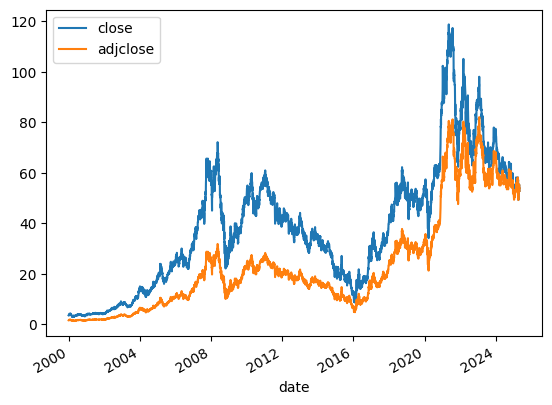

In [62]:
start_date = datetime.datetime(1960, 1, 1)
start_timestamp = calendar.timegm(start_date.timetuple())
end_date = datetime.datetime.today()
end_timestamp = calendar.timegm(end_date.timetuple())

ticker = 'VALE3.SA'
endpoint = f'https://query1.finance.yahoo.com/v8/finance/chart/{ticker}'
params = {
    'period1': start_timestamp,
    'period2': end_timestamp, # 2025-12-31
    'interval': '1d',
    'events': 'div,split'
}
headers = {
    'User-Agent': 'Mozilla/5.0'
}
r = requests.get(endpoint, params=params, headers=headers)
j = r.json()

# Pegando o resultado
result = j['chart']['result'][0]

# Timestamps (em segundos desde 1970)
timestamps = result['timestamp']

# Dados de OHLCV (Open, High, Low, Close, Volume)
quotes = result['indicators']['quote'][0]

# Criando o DataFrame
df = pd.DataFrame(quotes)

# Se houver preços ajustados (adjclose)
adjclose_data = result['indicators'].get('adjclose', [{}])[0]

# Parse dividendos
dividends = result.get('events', {}).get('dividends', {})
if dividends:
    div_df = pd.DataFrame.from_dict(dividends, orient='index')
    div_df['date'] = pd.to_datetime(div_df['date'], unit='s')
    div_df.set_index('date', inplace=True)
    df['dividends'] = div_df['amount']

# Parse splits
splits = result.get('events', {}).get('splits', {})
if splits:
    split_df = pd.DataFrame.from_dict(splits, orient='index')
    split_df['date'] = pd.to_datetime(split_df['date'], unit='s')
    split_df.set_index('date', inplace=True)
    df['splits'] = split_df['splitRatio']

df['adjclose'] = adjclose_data.get('adjclose', [None] * len(df))
df['date'] = pd.to_datetime(timestamps, unit='s')
df.set_index('date', inplace=True)

df[['close', 'adjclose']].plot()

<Axes: xlabel='date'>

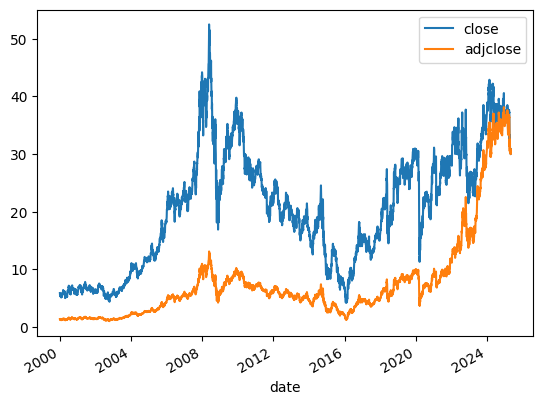